# 23 - Critical stations through every lens

Every notebook in this project answered the question *"which stations are critical?"* - and each one answered it differently. Notebook 03 said a critical station is a **cut vertex**. Notebook 04 said it's a station with high **betweenness** or high **service volume**. Notebook 05 said it's a station with no **walking alternative** nearby. The extension notebooks add more: **demand-weighted** importance (21), **peak-hour** importance (20), the **passenger time cost of closing the station** (22), and the role of a **multimodal transfer hub** (17).

These aren't the same question, and there's no reason they should give the same answers. A rural station can be a cut vertex and at the same time serve eight trips a day; a downtown platform can serve thousands of trips a day and be completely replaceable because three identical platforms stand across the street. This notebook is the synthesis step: it loads every lens that's actually available, ranks the stations under each one, measures how much the lenses agree with each other (Spearman correlation between the rankings, the number of overlaps in the top-50, and heatmaps for both measures), and then separates the stations that are critical under many lenses - the robustly critical ones - from stations that are critical under just one lens, which are usually byproducts of that lens's definition rather than real national vulnerabilities.

The product is a short, ranked list of nationally critical stations, each one with an explicit justification for why it qualifies. This is the item a transit planner can actually act on: not a column of centrality scores, but a short list of names with a justification attached to each.

**The research question here:** do the different definitions of "critical station" used across the project converge on the same stations, and which stations survive all of them?

## Input

The notebook is **tolerant of decay**: only the first input is required, and every other lens is loaded if its notebook was run, and skipped with an explicit message if it wasn't.

| Lens | Source table | Notebook | Required? |
|---|---|---|---|
| `betweenness` | `04*/tables/stop_metrics.csv` (`approx_betweenness`) | 04 | **Yes** (also supplies the station space) |
| `service_volume` | `04*/tables/stop_metrics.csv` (`weighted_degree`) | 04 | **Yes** |
| `articulation` | `03*/tables/articulation_points.csv` + `02*/tables/edges.csv` | 03, 02 | Optional |
| `no_walk_alternative` | `05*/tables/critical_isolation.csv` (`nearest_alt_m`) | 05 | Optional |
| `demand_weighted` | `21*/tables/demand_weighted_criticality.csv` | 21 | Optional |
| `peak_hour` | `20*/tables/peak_vs_offpeak_centrality.csv` (+ `19*/tables/window_summary.csv`) | 20, 19 | Optional |
| `closure_time_cost` | `22*/tables/rerouting_results.csv` | 22 | Optional |
| `multimodal` | `17*/tables/transfer_hubs.csv` (`n_modes`) | 17 | Optional |

**No raw GTFS is read here.** The file `stop_times.txt` is never touched, so there's no external download and no streaming step over 816 MB. Everything is a join over tables that earlier steps already wrote.

## Output

Everything is written under `outputs/nb/23_critical_station_lenses/`:

* `tables/critical_station_lenses.csv` - long format, one row per (station, lens): `stop_id, stop_name, lens, rank, score`.
* `tables/lens_agreement.csv` - one row per pair of lenses: `lens_a, lens_b, spearman_rho, top50_overlap`.
* `tables/lens_agreement_detail.csv` - the same pairs plus `n_common_stations`, so a weak correlation computed on a thin overlap isn't mistaken for a strong one.
* `tables/lens_coverage.csv` - what each lens measures, where it came from, and how many of the 30k stations it can actually score.
* `tables/station_lens_profile.csv` - every station with its rank and percentile under each lens.
* `tables/critical_station_shortlist.csv` - the final ranked shortlist meant for the planner, with a `reasons` column.
* `tables/lens_specific_stations.csv` - stations flagged by just one lens (candidate byproducts).
* `lens_synthesis_summary.json` - the headline numbers.
* `figures/lens_spearman_heatmap.png`, `lens_top_overlap_heatmap.png`, `stations_by_lens_count.png`, `shortlist_lens_profile.png`, `shortlist_map.png`, `lens_specific_counts.png`.

Nothing outside `outputs/nb/23_critical_station_lenses/` is written.

## Notebooks that must run first

**Required:** `04_centrality_analysis` (which itself needs `01` and `02`).
**Strongly recommended:** `02_graph_construction` (for exact articulation severity), `03_descriptive_analysis`, `05_critical_station_isolation`.
**Optional, and the reason to run this notebook again later:** `17`, `19`, `20`, `21`, `22`. With only `02`-`05` the notebook still runs and produces a comparison of four lenses; every extension notebook that was run adds another column to the matrix.

## 1. Initializing the working environment

The cell below lets the notebook run both on a local checkout and on Google Colab. It defines `_ensure(...)`, which pip-installs only the packages that are actually missing (so a repeat run of the notebook is cheap), and `find_repo_root()`, which climbs upward from the current directory looking for the GTFS folder, and if it isn't found, clones the repository into `/content`. It then sets `REPO`, `DATA`, and `OUT` and creates the notebook's output root. Every later cell relies on these three paths, so this cell has to run first.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Libraries, stage folders, and tunable constants

We import the scientific stack and fix the folder layout: this notebook owns `outputs/nb/23_critical_station_lenses/` with its `tables/` and `figures/` subfolders, and reads every other stage read-only.

All the knobs are collected here so a reviewer can change behavior in one place:

* `TOP_K = 50` defines what "critical under a lens" means - being inside that lens's top 50. The output column required by the project's data contract is literally named `top50_overlap`, so if you change `TOP_K` the column name no longer matches the software; the notebook prints a warning if you do.
* `MIN_LENSES_FOR_SHORTLIST = 2` keeps a station off the shortlist if it got there on the strength of a single lens that happens to be the only one covering it.
* `AP_SEVERITY_EXACT` is the one real cost knob. When it's `True` the notebook computes, for each articulation point, exactly how many stations are left outside the largest surviving component after that station is deleted. That's a single graph pass per cut vertex - roughly 900 passes over a graph of 30k nodes / 52k edges, about **30-60 seconds** in pure Python. Setting it to `False` falls back to ranking cut vertices by degree, which is fast but a distinctly worse proxy, and the notebook says so explicitly when it does.
* `UNREACHABLE_PENALTY_SECONDS` is only relevant if notebook 22 was run; see section 11 for why it exists and why it's an assumption rather than a measurement.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', font_scale=1.05)

STAGE = OUT / '23_critical_station_lenses'   # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
TOP_K = 50                          # "critical under a lens" = inside that lens's top K
MIN_LENSES_FOR_SHORTLIST = 2        # a station must be evaluated by >= this many lenses
SHORTLIST_SIZE = 40                 # rows in the final planner-facing shortlist
MIN_COMMON_FOR_RHO = 20             # skip Spearman when two lenses share fewer stations
AP_SEVERITY_EXACT = True            # exact cut-vertex severity (~30-60 s; see section 6)
UNREACHABLE_PENALTY_SECONDS = 3600  # cost charged per unit of unreachable demand (nb 22)
FIG_DPI = 150                       # figure resolution; drop to 90 for faster, smaller files
TOP_N_FIG = 25                      # rows in the profile heatmap and the bar figures

if TOP_K != 50:
    print(f'WARNING: TOP_K={TOP_K} but the contracted column name is "top50_overlap"; '
          'the column will hold top-' + str(TOP_K) + ' overlaps despite its name.')
print('this stage :', STAGE)

this stage : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\23_critical_station_lenses


## 3. Rendering Hebrew labels

Station names in the Israeli GTFS feed are in Hebrew, and some of the figures below print them (especially the shortlist profile heatmap). Matplotlib doesn't implement the Unicode bidirectional algorithm, so right-to-left text comes out reversed and unreadable. The cell below does a one-time monkey-patch of `matplotlib.text.Text.set_text` so that any string containing Hebrew characters is converted to display order with `python-bidi` before it's drawn, and picks a font that actually has Hebrew glyphs (Arial on Windows, DejaVu Sans everywhere else). It's idempotent - a repeat run won't stack a patch on top of a patch. All the other text in the notebook is in English, as the submission requires.

In [3]:
# Stop names are Hebrew. Whether they render reversed depends on the matplotlib build:
# most builds do NOT apply the Unicode bidi algorithm (so Hebrew must be reordered with
# python-bidi), but libraqm/raqm builds (some Colab installs, newer wheels) apply bidi
# themselves. We detect what THIS matplotlib does and only reorder when it does not, so
# labels render correctly on every environment and are never double-reversed.
_ensure("python-bidi")
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

def _mpl_reorders_hebrew():
    """True if matplotlib already applies the bidi algorithm itself (so get_display must NOT be applied)."""
    try:
        from matplotlib.figure import Figure
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        def _ink_cols(s):
            fig = Figure(figsize=(3, 1), dpi=100)
            FigureCanvasAgg(fig)
            ax = fig.add_axes([0, 0, 1, 1])
            ax.axis("off")
            ax.text(0.5, 0.5, s, fontsize=32, ha="center", va="center")
            fig.canvas.draw()
            prof = (np.asarray(fig.canvas.buffer_rgba())[:, :, :3].mean(2) < 128).sum(0).astype(float)
            nz = np.where(prof > 0)[0]
            return prof[nz.min():nz.max() + 1] if len(nz) else prof
        # Probe: Hebrew letters then digits. The digits are logically LAST, so in plain
        # logical order they render on the RIGHT; if matplotlib applies bidi they move LEFT.
        probe = _ink_cols("אבג12")
        tmpl = _ink_cols("12")
        n = len(tmpl)
        if n < 2 or len(probe) <= n:
            return False
        t = tmpl - tmpl.mean()
        best_c, best_off = -2.0, 0
        for off in range(len(probe) - n + 1):
            w = probe[off:off + n] - probe[off:off + n].mean()
            denom = ((w * w).sum() * (t * t).sum()) ** 0.5
            c = float((w * t).sum() / denom) if denom > 0 else 0.0
            if c > best_c:
                best_c, best_off = c, off
        return (best_off / (len(probe) - n)) < 0.5
    except Exception:
        return False

# Decide once, at import time, whether matplotlib already handles Hebrew.
_MPL_BIDI = _mpl_reorders_hebrew()

# Fail loudly only when we actually depend on python-bidi (matplotlib is NOT reordering).
# A broken or no-op build would make get_display a pass-through and render Hebrew reversed.
if not _MPL_BIDI and get_display("אבג") != "גבא":
    raise RuntimeError(
        "matplotlib does not reorder Hebrew and python-bidi is a no-op; Hebrew figure "
        "labels would render reversed. Reinstall a working build:\n"
        "    pip install -U --force-reinstall 'python-bidi>=0.6.7'"
    )

_HEBREW_RE = re.compile(r"[֐-׿]")

def fix_he(text):
    """Return display-ordered text. Left untouched for non-Hebrew, or when matplotlib already applies bidi."""
    if _MPL_BIDI or not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## 4. Locating earlier stages

This notebook reads up to eight other stages, and half of them may not exist yet. The helper functions below locate a stage folder by its **two-digit prefix** rather than its exact slug (`OUT.glob('04*')`), so a stage folder renamed from `04_centrality_analysis` to `04_centrality` is still found, and they search inside it recursively so it doesn't matter whether the stage wrote its CSVs at the folder root or under `tables/`.

There are two loading functions, and the difference between them is deliberate:

* `require_table` raises a `FileNotFoundError` naming the notebook you need to run first. It's used only for notebook 04, which supplies the station space every other lens is projected onto.
* `optional_table` prints a one-line `[skipped]` message naming the missing file and the notebook that would have produced it, records the gap in `MISSING_LENSES`, and returns `None`. The lens is simply absent from the comparison - the notebook doesn't invent a substitute.

Every id column is forced to `str` on read. Station ids in the Israeli GTFS look numeric, so reading one table without `dtype=str` would silently create integer keys and any merge against it would come back empty.

In [4]:
# --- Stage resolution and loading helpers ---------------------------------
ID_COLUMNS = ['stop_id', 'from_stop', 'to_stop', 'removed_stop']
MISSING_LENSES = []      # (lens label, notebook that would provide it, what was missing)


def stage_dir(prefix):
    """Resolve a stage folder by two-digit prefix, e.g. '04' -> 04_centrality_analysis."""
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    return matches[0] if matches else None


def find_artifact(prefix, filename):
    """Full path of `filename` inside the stage folder with this prefix, or None."""
    folder = stage_dir(prefix)
    if folder is None:
        return None
    direct = folder / filename
    if direct.exists():
        return direct
    matches = sorted(folder.rglob(filename))
    return matches[0] if matches else None


def _read(path):
    """Read a stage CSV, forcing every known identifier column to string."""
    return pd.read_csv(path, dtype={c: str for c in ID_COLUMNS}, encoding='utf-8-sig')


def require_table(prefix, filename, notebook):
    """Load a mandatory upstream table, or fail with an actionable message."""
    path = find_artifact(prefix, filename)
    if path is None:
        raise FileNotFoundError(
            f'{filename} was not found under outputs/nb/{prefix}* - run notebook '
            f'{notebook} first; it is the stage that writes {filename}.')
    df = _read(path)
    print(f'[required] {filename:<38} {len(df):>7,} rows  <-  {path}')
    return df


def optional_table(prefix, filename, notebook, lens_label):
    """Load an optional upstream table; return None with a clear message if absent."""
    path = find_artifact(prefix, filename)
    if path is None:
        MISSING_LENSES.append((lens_label, notebook, filename))
        print(f'[skipped ] lens "{lens_label}" unavailable: {filename} not found under '
              f'outputs/nb/{prefix}* - run notebook {notebook} to enable it.')
        return None
    df = _read(path)
    print(f'[loaded  ] {filename:<38} {len(df):>7,} rows  <-  {path}')
    return df


print('stages currently present under', OUT)
for folder in sorted(p.name for p in OUT.iterdir() if p.is_dir()):
    print('   ', folder)

stages currently present under C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb
    00_setup_and_data
    01_data_preparation
    02_graph_construction
    03_descriptive_analysis
    04_centrality_analysis
    05_critical_station_isolation
    06_robustness_analysis
    07_regional_comparison
    08_community_detection
    09_socioeconomic_equity
    10_network_model_comparison
    11_rail_network_analysis
    12_rail_socioeconomic
    13_embeddings_link_prediction
    14_multimodal_inventory
    15_bus_network
    16_lightrail_and_minor_modes
    17_multimodal_transfer_hubs
    18_travel_time_network
    19_time_of_day_graphs
    20_dynamic_resilience
    21_demand_weighted_criticality
    22_rerouting_model
    23_critical_station_lenses


## 5. The station space (the backbone)

Every lens has to be projected onto the same shared set of stations, otherwise "rank 3 under lens A" and "rank 3 under lens B" aren't comparable. We use notebook 04's `stop_metrics.csv` as the backbone, because it covers exactly the active stations of the trip-adjacency graph (about 30,463 stations) and carries the name, coordinates, and district we need for the figures and the final shortlist.

A lens may cover fewer stations than the backbone - that's expected, and it's the most important caveat in the notebook. The isolation lens from notebook 05, for instance, evaluated only a pre-filtered subset of stations. Any station a lens doesn't cover is recorded as **not evaluated**, never as "scored zero": treating an unevaluated station as if it weren't important would silently convert a coverage gap into a finding.

In [5]:
# --- Station universe from notebook 04 ------------------------------------
metrics = require_table('04', 'stop_metrics.csv', '04_centrality_analysis')
metrics['stop_id'] = metrics['stop_id'].astype(str).str.strip()
metrics = metrics.drop_duplicates(subset='stop_id')

for needed in ('approx_betweenness', 'weighted_degree', 'stop_name', 'lat', 'lon'):
    if needed not in metrics.columns:
        raise KeyError(f'stop_metrics.csv has no "{needed}" column - re-run notebook 04; '
                       f'columns found: {list(metrics.columns)}')

keep = ['stop_id', 'stop_name', 'lat', 'lon', 'region']
keep = [c for c in keep if c in metrics.columns]
spine = metrics[keep].copy()
if 'region' not in spine.columns:
    spine['region'] = 'Unknown'

SPINE_IDS = set(spine['stop_id'])
NAME_BY_ID = dict(zip(spine['stop_id'], spine['stop_name']))
print(f'station universe: {len(spine):,} active stops')
spine.head()

[required] stop_metrics.csv                        30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\04_centrality_analysis\tables\stop_metrics.csv
station universe: 30,463 active stops


,stop_id,stop_name,lat,lon,region
0,13103,קניון עזריאלי/דרך מנחם בגין,32.074592,34.790584,Center
1,10775,גשר המיתרים/שד' הרצל,31.787162,35.199533,Jerusalem
2,10716,צומת רמות/גולדה,31.808253,35.204001,Jerusalem
3,12910,דרך נמיר/יהודה המכבי,32.095376,34.794137,Center
4,13358,סמינר הקיבוצים/דרך נמיר,32.101886,34.792779,Center


## 6. The lens registry

`register_lens` is the one place where a raw column from an earlier stage becomes a comparable ranking. It takes a table, an id column, and a score column, and does five things:

1. **Orients the score.** Every lens is stored so that a *higher score means more critical*. Lenses whose natural metric points the other way (a rank number, where 1 is worst) get `higher_is_worse=False` and the stored score is sign-flipped. That's why the `score` column in the exported long table is a criticality score rather than a literal copy of the original metric - the sign convention has to be uniform for the comparisons below to mean anything.
2. **Removes duplicates** down to one row per station (taking the worst value if a table repeats a station).
3. **Restricts to the backbone**, reporting how many rows it had to drop because the station isn't in the trip-adjacency graph.
4. **Ranks** with `method='min'`, so tied stations share a rank - important because some lenses have long ties (detours and demand ranks in small integer values).
5. **Computes a percentile** of the score within the lens's own coverage set, giving a value in the range (0, 1] that's comparable across lenses with completely different units (seconds, meters, trips, unitless betweenness).

A lens that's missing, empty, or lacks the requested column is skipped with a message and simply doesn't appear in the comparison.

In [6]:
# --- Lens registry --------------------------------------------------------
LENSES = {}      # lens name -> DataFrame[stop_id, score, rank, pct]
LENS_META = {}   # lens name -> provenance and coverage record


def register_lens(name, df, id_col, score_col, higher_is_worse=True,
                  question='', source=''):
    """Turn one upstream column into a ranked, percentiled lens over the spine."""
    if df is None:
        return None
    for col in (id_col, score_col):
        if col not in df.columns:
            print(f'[skipped ] lens "{name}": source table has no "{col}" column '
                  f'(found: {list(df.columns)[:8]} ...).')
            MISSING_LENSES.append((name, source, 'column ' + col))
            return None

    sub = df[[id_col, score_col]].copy()
    sub.columns = ['stop_id', 'score']
    sub['stop_id'] = sub['stop_id'].astype(str).str.strip()
    sub['score'] = pd.to_numeric(sub['score'], errors='coerce')
    if not higher_is_worse:
        sub['score'] = -sub['score']          # store so that higher always = more critical
    sub = sub.dropna(subset=['stop_id', 'score'])
    sub = sub.groupby('stop_id', as_index=False)['score'].max()

    before = len(sub)
    sub = sub[sub['stop_id'].isin(SPINE_IDS)]
    dropped = before - len(sub)
    if len(sub) < 2:
        print(f'[skipped ] lens "{name}": fewer than two usable stations after cleaning.')
        MISSING_LENSES.append((name, source, 'no usable rows'))
        return None

    sub['rank'] = sub['score'].rank(ascending=False, method='min').astype(int)
    sub['pct'] = sub['score'].rank(ascending=True, pct=True)
    sub = sub.sort_values('rank').reset_index(drop=True)

    LENSES[name] = sub
    LENS_META[name] = {
        'lens': name,
        'question': question,
        'source': source,
        'metric': score_col,
        'higher_metric_is_more_critical': bool(higher_is_worse),
        'stations_evaluated': int(len(sub)),
        'coverage_share_of_universe': round(len(sub) / len(SPINE_IDS), 4),
        'rows_dropped_outside_universe': int(dropped),
    }
    print(f'[lens ok ] {name:<20} {len(sub):>7,} stations '
          f'({len(sub) / len(SPINE_IDS):.1%} of the universe), metric = {score_col}')
    return sub

## 7. Lens (a) topological betweenness and lens (c) service volume

Both come straight from notebook 04 and both cover the full space, so they serve as the anchor for comparison.

* **`betweenness`** uses `approx_betweenness` - the share of shortest paths passing through the station. This is the classic "if it fails, traffic has to route around it" measure. Note that it's *approximate*: notebook 04 computed it by sampling pivots, and its own stability table shows the ranking is stable at the head but noisy in the tail. Rank differences of a few places should be treated as meaningless.
* **`service_volume`** uses `weighted_degree` - the total number of scheduled trips touching the station. This is the operational rather than topological reading of importance, and it's the only lens here that reflects how much service actually exists rather than where the station sits in the graph.

The two are deliberately kept separate rather than merged into a single "centrality" lens, because the whole point of the notebook is to test whether they agree.

In [7]:
# --- Lens (a): topological betweenness ------------------------------------
register_lens(
    'betweenness', metrics, 'stop_id', 'approx_betweenness', higher_is_worse=True,
    question='Which stations carry the most shortest paths through the network?',
    source='04_centrality_analysis/tables/stop_metrics.csv')

# --- Lens (c): service volume ---------------------------------------------
register_lens(
    'service_volume', metrics, 'stop_id', 'weighted_degree', higher_is_worse=True,
    question='Which stations carry the largest scheduled trip volume?',
    source='04_centrality_analysis/tables/stop_metrics.csv')

[lens ok ] betweenness           30,463 stations (100.0% of the universe), metric = approx_betweenness
[lens ok ] service_volume        30,463 stations (100.0% of the universe), metric = weighted_degree


,stop_id,score,rank,pct
0,13103,21396.0,1,1.000000
1,10775,18976.0,2,0.999967
2,10716,17392.0,3,0.999934
3,12910,16816.0,4,0.999902
4,13358,15780.0,5,0.999869
...,...,...,...,...
30458,19229,2.0,30452,0.000230
30459,50287,2.0,30452,0.000230
30460,43634,2.0,30452,0.000230
30461,47994,2.0,30452,0.000230


## 8. Lens (b) articulation points, ranked by the damage they actually cause

Notebook 03 counts the roughly 900 cut vertices, but being a cut vertex is a **binary** property, and a binary property can't be ranked. Most of those 900 are the neck of a short dead-end branch: removing them isolates three stations. A handful sit between genuinely large parts of the network. Comparing a binary flag against a continuous lens would also drain the Spearman correlations of meaning (one variable would be all ties).

So we compute a severity for each cut vertex: **how many stations are left outside the largest surviving component when that station is deleted**. The code builds a plain adjacency dictionary from `02*/edges.csv` (undirected projection, self-loops removed), and for each cut vertex runs a single iterative depth-first pass starting from each of its neighbors while the node itself is marked blocked. The set of visited nodes is shared across a single node's branches, so each component is scanned exactly once and the whole pass costs `O(V + E)` *for that node's component alone*.

**Cost:** about 900 passes over a graph of 30k nodes / 52k edges in pure Python, about **30-60 seconds**. Setting `AP_SEVERITY_EXACT = False` skips this - the notebook then ranks cut vertices by degree and prints an explicit warning, because degree is a poor substitute for the size of the disconnection (a degree-2 station can be the only link to an entire town).

This lens's space is the roughly 900 cut vertices, not all 30k stations. Correlations involving it therefore answer the question "among cut vertices, does the size of the disconnection track the other lenses?" - which is the right question, but narrower than it looks.

In [8]:
# --- Lens (b): articulation points with an exact severance score ------------
ap_df = optional_table('03', 'articulation_points.csv', '03_descriptive_analysis',
                       'articulation')
edges_path = find_artifact('02', 'edges.csv')
ap_score_col = None

if ap_df is not None:
    ap_df = ap_df.copy()
    ap_df['stop_id'] = ap_df['stop_id'].astype(str).str.strip()

if ap_df is not None and edges_path is not None and AP_SEVERITY_EXACT:
    edges_df = _read(edges_path)
    adj = {}
    for u, v in zip(edges_df['from_stop'].astype(str), edges_df['to_stop'].astype(str)):
        if u == v:
            continue                     # self-loops carry no connectivity information
        adj.setdefault(u, set()).add(v)
        adj.setdefault(v, set()).add(u)
    print(f'undirected adjacency built: {len(adj):,} nodes')

    def _explore(start, visited):
        """Iterative DFS from `start`, skipping anything already in `visited`."""
        stack, members = [start], []
        visited.add(start)
        while stack:
            x = stack.pop()
            members.append(x)
            for y in adj[x]:
                if y not in visited:
                    visited.add(y)
                    stack.append(y)
        return members

    comp_size, _seen = {}, set()
    for node in adj:
        if node in _seen:
            continue
        members = _explore(node, _seen)
        for m in members:
            comp_size[m] = len(members)

    def stranded_nodes(v):
        """Stations left outside the largest surviving fragment when v is deleted."""
        blocked, sizes = {v}, []
        for start in adj[v]:
            if start in blocked:
                continue
            stack, count = [start], 0
            blocked.add(start)
            while stack:
                x = stack.pop()
                count += 1
                for y in adj[x]:
                    if y not in blocked:
                        blocked.add(y)
                        stack.append(y)
            sizes.append(count)
        return 0 if not sizes else sum(sizes) - max(sizes)

    ap_df = ap_df[ap_df['stop_id'].isin(adj)].copy()
    ap_df['stranded_nodes'] = [stranded_nodes(s) for s in ap_df['stop_id']]
    ap_df['component_size'] = [comp_size[s] for s in ap_df['stop_id']]
    ap_score_col = 'stranded_nodes'
    ap_df.sort_values('stranded_nodes', ascending=False).head(10).to_csv(
        TABLES / 'top_articulation_severity.csv', index=False, encoding='utf-8-sig')
    print(f'exact severance computed for {len(ap_df):,} cut vertices; '
          f'worst strands {int(ap_df["stranded_nodes"].max()):,} stations, '
          f'median strands {ap_df["stranded_nodes"].median():.0f}')

elif ap_df is not None:
    ap_score_col = 'degree' if 'degree' in ap_df.columns else None
    print('[fallback] ranking cut vertices by DEGREE, not by severance size, because '
          'edges.csv from notebook 02 is missing or AP_SEVERITY_EXACT is False. '
          'Degree is a weak proxy: a degree-2 stop can be the sole link to a whole town.')

if ap_df is not None and ap_score_col is not None:
    register_lens(
        'articulation', ap_df, 'stop_id', ap_score_col, higher_is_worse=True,
        question='Among cut vertices, which one strands the most stations when removed?',
        source='03_descriptive_analysis/tables/articulation_points.csv (+ 02 edges.csv)')

[loaded  ] articulation_points.csv                    900 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\03_descriptive_analysis\tables\articulation_points.csv


undirected adjacency built: 30,463 nodes


exact severance computed for 900 cut vertices; worst strands 39 stations, median strands 2
[lens ok ] articulation             900 stations (3.0% of the universe), metric = stranded_nodes


## 9. Lens (d) no walking alternative

Notebook 05 measured, for each station it examined, the straight-line distance to the nearest *other* station that could absorb its passengers (`nearest_alt_m`). A large value means a passenger stranded there has nowhere to walk to: the station isn't replaceable on the ground, regardless of what the graph says.

**We should be honest about what this lens covers.** Notebook 05 didn't evaluate all of the roughly 30k stations; it evaluated a pre-filtered set of stations it had already flagged as critical (about 3,000 rows), and within those, the vast majority have an alternative within 300 m. So this lens is *conditional*: it ranks lack of replaceability **among stations already considered important**, and says nothing at all about the other roughly 27k stations. Two conclusions follow, and both are handled explicitly below: its correlations with other lenses are computed on that subset only, and a station absent from it is recorded as not evaluated rather than as "has an alternative".

In [9]:
# --- Lens (d): distance to the nearest substitutable stop -------------------
iso = optional_table('05', 'critical_isolation.csv', '05_critical_station_isolation',
                     'no_walk_alternative')
if iso is not None:
    print(f'coverage note: notebook 05 evaluated {len(iso):,} pre-filtered stops, i.e. '
          f'{len(iso) / len(SPINE_IDS):.1%} of the universe - this lens is conditional '
          'on a station already having been flagged critical upstream.')
    if 'is_isolated' in iso.columns:
        flagged = int(pd.Series(iso['is_isolated']).astype(str).str.lower()
                      .isin(['true', '1', 'yes']).sum())
        print(f'   of those, {flagged:,} were flagged as genuinely isolated upstream.')

register_lens(
    'no_walk_alternative', iso, 'stop_id', 'nearest_alt_m', higher_is_worse=True,
    question='Which stations have no substitutable stop within walking distance?',
    source='05_critical_station_isolation/tables/critical_isolation.csv')

[loaded  ] critical_isolation.csv                   3,047 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\05_critical_station_isolation\tables\critical_isolation.csv
coverage note: notebook 05 evaluated 3,047 pre-filtered stops, i.e. 10.0% of the universe - this lens is conditional on a station already having been flagged critical upstream.
   of those, 56 were flagged as genuinely isolated upstream.
[lens ok ] no_walk_alternative    3,047 stations (10.0% of the universe), metric = nearest_alt_m


,stop_id,score,rank,pct
0,8427,5267.577366,1,1.000000
1,34571,4648.171894,2,0.999672
2,27934,4189.103726,3,0.999344
3,7613,4114.644665,4,0.999015
4,8044,2378.135261,5,0.998687
...,...,...,...,...
3042,47944,0.000000,2990,0.009682
3043,47928,0.000000,2990,0.009682
3044,47918,0.000000,2990,0.009682
3045,47983,0.000000,2990,0.009682


## 10. Lens (e) demand-weighted criticality

Notebook 21 re-ranks stations by combining topological importance with the population the station serves, so a structurally interesting station in an empty area drops, and a routine station serving 40,000 people rises. We prefer its `demand_weighted_rank` column (a rank, where 1 is most critical - hence `higher_is_worse=False`, which flips the sign so the stored score keeps the project-wide convention). If only the intermediate file `demand_proxy.csv` exists, we fall back to its `demand_weight` column.

If notebook 21 wasn't run, this lens is skipped. We deliberately do **not** improvise a substitute from notebook 09's socioeconomic table: a population attached to a station via spatial join is exactly the proxy that notebook 21 is responsible for building and validating, and rebuilding it here under different assumptions would produce a second, silently inconsistent version of the same quantity.

In [10]:
# --- Lens (e): demand-weighted criticality ---------------------------------
dem = optional_table('21', 'demand_weighted_criticality.csv',
                     '21_demand_weighted_criticality', 'demand_weighted')

if dem is not None and 'demand_weighted_rank' in dem.columns:
    register_lens(
        'demand_weighted', dem, 'stop_id', 'demand_weighted_rank', higher_is_worse=False,
        question='Which stations matter most once the population served is weighted in?',
        source='21_demand_weighted_criticality/tables/demand_weighted_criticality.csv')
else:
    proxy = optional_table('21', 'demand_proxy.csv', '21_demand_weighted_criticality',
                           'demand_weighted (proxy fallback)')
    if proxy is not None:
        print('[fallback] using demand_proxy.demand_weight; this is raw served demand, '
              'not the demand-weighted criticality ranking itself.')
    register_lens(
        'demand_weighted', proxy, 'stop_id', 'demand_weight', higher_is_worse=True,
        question='Which stations serve the most demand (proxy fallback)?',
        source='21_demand_weighted_criticality/tables/demand_proxy.csv')

[loaded  ] demand_weighted_criticality.csv         30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\21_demand_weighted_criticality\tables\demand_weighted_criticality.csv
[lens ok ] demand_weighted       30,463 stations (100.0% of the universe), metric = demand_weighted_rank


## 11. Lens (f) peak-hour criticality

Notebook 20 recomputes centrality separately for each time window built in notebook 19, because the network at 08:00 isn't the network at 23:00 - branches that run only at rush hour exist in one and not the other. This lens takes the **peak** window only.

Selecting that window has to be robust to whatever names notebook 19 chose, so the selection is: prefer window names containing `peak` but not `off`; if several windows qualify, use notebook 19's `window_summary.csv` to take the one with the most trips; and if that table isn't available, take the first candidate alphabetically. The chosen window is printed, so the choice is never silent. Within the window we rank by `approx_betweenness`, falling back to `weighted_degree` if the betweenness column doesn't exist.

In [11]:
# --- Lens (f): peak-hour criticality ---------------------------------------
peak = optional_table('20', 'peak_vs_offpeak_centrality.csv', '20_dynamic_resilience',
                      'peak_hour')
peak_window = None

if peak is not None and 'window' in peak.columns:
    windows = sorted({str(w) for w in peak['window'].dropna()})
    named = [w for w in windows if 'peak' in w.lower() and 'off' not in w.lower()]
    candidates = named or windows
    ws_path = find_artifact('19', 'window_summary.csv')
    if len(candidates) > 1 and ws_path is not None:
        ws = _read(ws_path)
        ws['window'] = ws['window'].astype(str)
        busiest = ws[ws['window'].isin(candidates)]
        if 'trips' in busiest.columns and len(busiest):
            candidates = [busiest.sort_values('trips', ascending=False).iloc[0]['window']]
    peak_window = str(candidates[0])
    print(f'windows available: {windows}')
    print(f'peak window selected: "{peak_window}"')
    peak = peak[peak['window'].astype(str) == peak_window].copy()

peak_metric = 'weighted_degree'
if peak is not None and 'approx_betweenness' in peak.columns:
    peak_metric = 'approx_betweenness'

register_lens(
    'peak_hour', peak, 'stop_id', peak_metric, higher_is_worse=True,
    question='Which stations are critical specifically during the peak window?',
    source='20_dynamic_resilience/tables/peak_vs_offpeak_centrality.csv'
           + (f' [window={peak_window}]' if peak_window else ''))

[loaded  ] peak_vs_offpeak_centrality.csv         145,650 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\tables\peak_vs_offpeak_centrality.csv
windows available: ['afternoon_peak', 'evening', 'midday', 'morning_peak', 'night']
peak window selected: "afternoon_peak"


[lens ok ] peak_hour             30,057 stations (98.7% of the universe), metric = approx_betweenness


,stop_id,score,rank,pct
0,41133,0.160713,1,1.000000
1,17303,0.114018,2,0.999967
2,41132,0.097520,3,0.999933
3,27689,0.087206,4,0.999900
4,16491,0.070934,5,0.999867
...,...,...,...,...
30052,17772,0.000000,27310,0.045730
30053,43715,0.000000,27310,0.045730
30054,34583,0.000000,27310,0.045730
30055,43708,0.000000,27310,0.045730


## 12. Lens (g) passenger time cost of closing the station

Notebook 22 closes one station at a time on the travel-time graph and measures how much everyone else's trip gets longer. This is the closest thing in the project to a real impact measure, because it's denominated in seconds of passenger time rather than graph units.

There's one modeling decision here that should be stated openly. `mean_detour_seconds` is an average over the pairs that are **still reachable** after the closure. A station whose removal disconnects a whole region can therefore record a *low* average detour, simply because the trips hit hardest dropped out of the average entirely - the metric rewards catastrophic failure. To prevent that inversion we explicitly charge for unreachability:

```
closure_cost_seconds = mean_detour_seconds + UNREACHABLE_PENALTY_SECONDS * (1 - reachable_share)
```

`UNREACHABLE_PENALTY_SECONDS = 3600` says "treat a trip that became impossible as if it cost an hour". This number is an **assumption, not a measurement** - the real cost of an impossible trip isn't bounded. It's a named constant precisely so its effect can be examined: raise it and disconnecting stations take over the lens, set it to 0 and you get the raw average detour (and the inversion). If notebook 22 doesn't export `reachable_share`, the raw average detour is used and the caveat above stands with no relief.

In [12]:
# --- Lens (g): passenger-time cost under closure ---------------------------
rr = optional_table('22', 'rerouting_results.csv', '22_rerouting_analysis',
                    'closure_time_cost')

if rr is not None and 'mean_detour_seconds' in rr.columns:
    rr = rr.copy()
    cost = pd.to_numeric(rr['mean_detour_seconds'], errors='coerce').fillna(0.0)
    if 'reachable_share' in rr.columns:
        lost = 1.0 - pd.to_numeric(rr['reachable_share'], errors='coerce').clip(0, 1).fillna(1.0)
        cost = cost + UNREACHABLE_PENALTY_SECONDS * lost
        print(f'unreachable demand charged at {UNREACHABLE_PENALTY_SECONDS:,} s '
              '(an assumption, see the markdown above)')
    else:
        print('[caveat  ] rerouting_results.csv has no reachable_share column, so the '
              'mean detour is used raw - stations that disconnect the network are '
              'under-rated by this lens.')
    rr['closure_cost_seconds'] = cost

register_lens(
    'closure_time_cost', rr, 'removed_stop', 'closure_cost_seconds', higher_is_worse=True,
    question='Which closures cost passengers the most travel time?',
    source='22_rerouting_analysis/tables/rerouting_results.csv')

[loaded  ] rerouting_results.csv                       30 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\tables\rerouting_results.csv
unreachable demand charged at 3,600 s (an assumption, see the markdown above)
[lens ok ] closure_time_cost         30 stations (0.1% of the universe), metric = closure_cost_seconds


,stop_id,score,rank,pct
0,9048,435.372727,1,1.000000
1,27689,194.832500,2,0.966667
2,39085,180.500000,3,0.933333
3,14348,158.287500,4,0.900000
4,41132,157.548750,5,0.866667
5,19486,152.000000,6,0.833333
6,17303,151.900000,7,0.800000
7,29243,147.363750,8,0.766667
8,7562,142.753731,9,0.733333
9,12975,142.427719,10,0.700000


## 13. Lens (h) multimodal transfer - loaded for context, EXCLUDED from the synthesis

**This lens is intentionally left out of the seven-lens comparison.** We still load notebook 17's table (and print its mode counts below) for transparency, but we do not register it as a lens: GTFS records almost no shared `stop_id` across modes, so `n_modes` is a weak, heavily-tied signal (most stations are 1, a few hundred are 2) that mostly adds noise to the agreement matrix. The seven substantive lenses (a-g) carry the synthesis. To restore it, uncomment the `register_lens` call in the cell below.

Notebook 17 counts how many distinct modes (bus, rail, light rail, trolleybus, cable car, and demand-based service) meet at each station. A station where four modes interchange is critical in a different way than a high-betweenness station: losing it doesn't just lengthen routes, it breaks the transfer that makes a multi-leg trip possible at all, and usually there's no second place nearby where those two modes meet.

`n_modes` is a small integer, so this lens has very heavy ties - most stations are 1, a few hundred are 2, and a handful are 3 or more. Rank ties are handled with `method='min'`, but the practical meaning is that its "top 50" is an arbitrary slice out of a large tie group. Its overlap counts should be read with that in mind; the correlation coefficient is more informative than the top-50 count for this lens.

In [13]:
# --- Lens (h): multimodal interchange --------------------------------------
hubs = optional_table('17', 'transfer_hubs.csv', '17_multimodal_transfer_hubs',
                      'multimodal')

if hubs is not None and 'n_modes' in hubs.columns:
    counts = pd.to_numeric(hubs['n_modes'], errors='coerce').value_counts().sort_index()
    print('modes served -> number of stops:')
    print(counts.to_string())

# The multimodal interchange lens is deliberately EXCLUDED from the synthesis, so
# this notebook compares the seven substantive lenses (a-g). GTFS records almost
# no shared stop_id across modes (see notebook 17: strict multimodal stops are
# largely a data-entry artefact, and the real interchanges are a walking-distance
# phenomenon the feed does not encode), so n_modes is a weak, heavily-tied signal
# that mostly adds noise to the agreement matrix. To restore it, uncomment below.
# register_lens(
#     'multimodal', hubs, 'stop_id', 'n_modes', higher_is_worse=True,
#     question='Which stations are the interchange point between several modes?',
#     source='17_multimodal_transfer_hubs/tables/transfer_hubs.csv')

[loaded  ] transfer_hubs.csv                       30,466 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\tables\transfer_hubs.csv
modes served -> number of stops:
n_modes
1    30385
2       81


## 14. What we actually got

Before any comparison, we record exactly which lenses exist in this run and how much of the network each one can see. `lens_coverage.csv` is the notebook's honesty record: every correlation and every shortlist rank below has to be read against it, because a lens covering 3,000 stations and a lens covering 30,000 aren't equally informative even when they produce a number that looks the same.

The comparison needs at least two lenses to have any meaning, so the cell stops with a clear message if fewer than two survived.

In [14]:
# --- Lens inventory --------------------------------------------------------
if len(LENSES) < 2:
    raise RuntimeError(
        f'only {len(LENSES)} lens/lenses could be built, so there is nothing to compare. '
        'Run notebooks 03, 04 and 05 first (04 is mandatory), then re-run this notebook.')

lens_names = list(LENSES)
coverage = (pd.DataFrame([LENS_META[n] for n in lens_names])
            .sort_values('stations_evaluated', ascending=False)
            .reset_index(drop=True))
coverage.to_csv(TABLES / 'lens_coverage.csv', index=False, encoding='utf-8-sig')

print(f'{len(lens_names)} lenses available: {lens_names}')
if MISSING_LENSES:
    print('\nlenses NOT available in this run:')
    for label, notebook, what in MISSING_LENSES:
        print(f'   {label:<32} needs {notebook}  (missing: {what})')
else:
    print(f'all {len(lens_names)} lenses were available (multimodal excluded by design).')

coverage[['lens', 'metric', 'stations_evaluated', 'coverage_share_of_universe']]

7 lenses available: ['betweenness', 'service_volume', 'articulation', 'no_walk_alternative', 'demand_weighted', 'peak_hour', 'closure_time_cost']
all 7 lenses were available (multimodal excluded by design).


,lens,metric,stations_evaluated,coverage_share_of_universe
0,betweenness,approx_betweenness,30463,1.0000
1,service_volume,weighted_degree,30463,1.0000
2,demand_weighted,demand_weighted_rank,30463,1.0000
3,peak_hour,approx_betweenness,30057,0.9867
4,no_walk_alternative,nearest_alt_m,3047,0.1000
5,articulation,stranded_nodes,900,0.0295
6,closure_time_cost,closure_cost_seconds,30,0.0010


## 15. The long table: every station under every lens

`critical_station_lenses.csv` is the contract output of this stage and the raw material for everything that comes after it: one row per (station, lens) pair with the rank and the criticality score, in long format, so that adding a ninth lens later changes the row count and not the schema. Remember that `score` follows the project-wide convention - higher is always more critical - so for a lens whose original metric was a rank number, the stored score is its inverse. The `rank` column is the human-readable one: 1 is the most critical station under that lens.

In [15]:
# --- Long table: one row per (station, lens) -------------------------------
long_parts = []
for name in lens_names:
    part = LENSES[name][['stop_id', 'rank', 'score']].copy()
    part.insert(1, 'lens', name)
    long_parts.append(part)

lenses_long = pd.concat(long_parts, ignore_index=True)
lenses_long['stop_name'] = lenses_long['stop_id'].map(NAME_BY_ID)
lenses_long = (lenses_long[['stop_id', 'stop_name', 'lens', 'rank', 'score']]
               .sort_values(['lens', 'rank'])
               .reset_index(drop=True))
lenses_long.to_csv(TABLES / 'critical_station_lenses.csv', index=False, encoding='utf-8-sig')

print(f'critical_station_lenses.csv: {len(lenses_long):,} rows '
      f'({lenses_long["stop_id"].nunique():,} distinct stations x {len(lens_names)} lenses)')
lenses_long.groupby('lens').head(3).head(24)

critical_station_lenses.csv: 125,423 rows (30,463 distinct stations x 7 lenses)


,stop_id,stop_name,lens,rank,score
0,35356,שער הגלבוע/אתר הסקי,articulation,1,39.000000
1,11156,קיבוץ צובה,articulation,2,36.000000
2,37358,תל אביב מרכז,articulation,3,33.000000
900,17303,ת.התרעננות/דור אלון מגל 6,betweenness,1,0.112460
901,41133,מחלף חמד,betweenness,2,0.087536
902,27689,מחלף קמה לצפון,betweenness,3,0.071648
31363,9048,בן גוריון/שערי ירושלים,closure_time_cost,1,435.372727
31364,27689,מחלף קמה לצפון,closure_time_cost,2,194.832500
31365,39085,בית ספר ניסויי תפן,closure_time_cost,3,180.500000
31393,41133,מחלף חמד,demand_weighted,1,-1.000000


## 16. Do the lenses agree? Spearman correlation and top-K overlap

For each pair of lenses we compute two very different things, on purpose:

* **Spearman rank correlation** over the stations that *both* lenses evaluated. It answers "do these two orderings agree across the whole network?". It's computed pairwise-complete, so a pair involving a narrow lens is computed on that narrow overlap only - which is why `n_common_stations` is exported alongside it in `lens_agreement_detail.csv`, and why pairs with fewer than `MIN_COMMON_FOR_RHO` common stations are left blank instead of being reported as coincidence.
* **Top-K overlap**: how many of those stations appear in the top 50 of both lenses. This is the answer to the question a planner actually asks, which isn't "are the orderings similar in general" but "do the two definitions point me at the same handful of stations". The two can split sharply: two lenses can correlate at rho = 0.8 across 30,000 stations and still share only a handful of names right at the top, because a rank correlation is dominated by the vast, uninteresting middle of the distribution.

Spearman is used rather than Pearson because the lens scores are in incompatible units (seconds, meters, trips, ranks) and some of them are heavily skewed; only the order is comparable.

In [16]:
# --- Pairwise agreement between lenses -------------------------------------
topk_sets = {n: set(LENSES[n].sort_values('rank')['stop_id'].head(TOP_K))
             for n in lens_names}

pair_rows = []
for i, a in enumerate(lens_names):
    for b in lens_names[i + 1:]:
        da = LENSES[a][['stop_id', 'score']].rename(columns={'score': 'score_a'})
        db = LENSES[b][['stop_id', 'score']].rename(columns={'score': 'score_b'})
        both = da.merge(db, on='stop_id', how='inner')
        if len(both) >= MIN_COMMON_FOR_RHO:
            rho = float(spearmanr(both['score_a'], both['score_b'])[0])
        else:
            rho = float('nan')
        pair_rows.append({
            'lens_a': a,
            'lens_b': b,
            'spearman_rho': round(rho, 4),
            'top50_overlap': int(len(topk_sets[a] & topk_sets[b])),
            'n_common_stations': int(len(both)),
        })

agreement = pd.DataFrame(pair_rows)
# contracted file: exactly the four agreed columns
agreement[['lens_a', 'lens_b', 'spearman_rho', 'top50_overlap']].to_csv(
    TABLES / 'lens_agreement.csv', index=False, encoding='utf-8-sig')
# diagnostic file: the same pairs plus the overlap size the rho was computed on
agreement.to_csv(TABLES / 'lens_agreement_detail.csv', index=False, encoding='utf-8-sig')

thin = agreement[agreement['spearman_rho'].isna()]
if len(thin):
    print(f'{len(thin)} lens pair(s) share fewer than {MIN_COMMON_FOR_RHO} stations; '
          'their correlation is left blank rather than reported.')
agreement.sort_values('top50_overlap', ascending=False)

1 lens pair(s) share fewer than 20 stations; their correlation is left blank rather than reported.


,lens_a,lens_b,spearman_rho,top50_overlap,n_common_stations
4,betweenness,peak_hour,0.8232,31,30057
5,betweenness,closure_time_cost,0.2439,30,30
3,betweenness,demand_weighted,0.8163,27,30463
18,demand_weighted,peak_hour,0.6971,21,30057
20,peak_hour,closure_time_cost,0.3802,18,30
19,demand_weighted,closure_time_cost,0.2888,17,30
8,service_volume,demand_weighted,0.4506,9,30463
9,service_volume,peak_hour,0.1893,4,30057
0,betweenness,service_volume,0.1868,4,30463
10,service_volume,closure_time_cost,0.1426,4,30


## 17. Heatmaps of the agreement

Two square matrices built from the pairs table above. The left one is the Spearman matrix on a red-blue diverging scale fixed to [-1, 1], so the color is comparable across runs and an empty cell means "too little overlap to say" rather than "zero correlation". The right one counts shared members in the top 50; its diagonal is the size of each lens's top-K set, which is usually 50 but can be smaller for a lens covering fewer than 50 stations.

Reading them together is the whole point of the section. High correlation next to low top-50 overlap means the lenses agree broadly about the country but disagree about the extremes - and the extremes are the ones that get maintenance budgets.

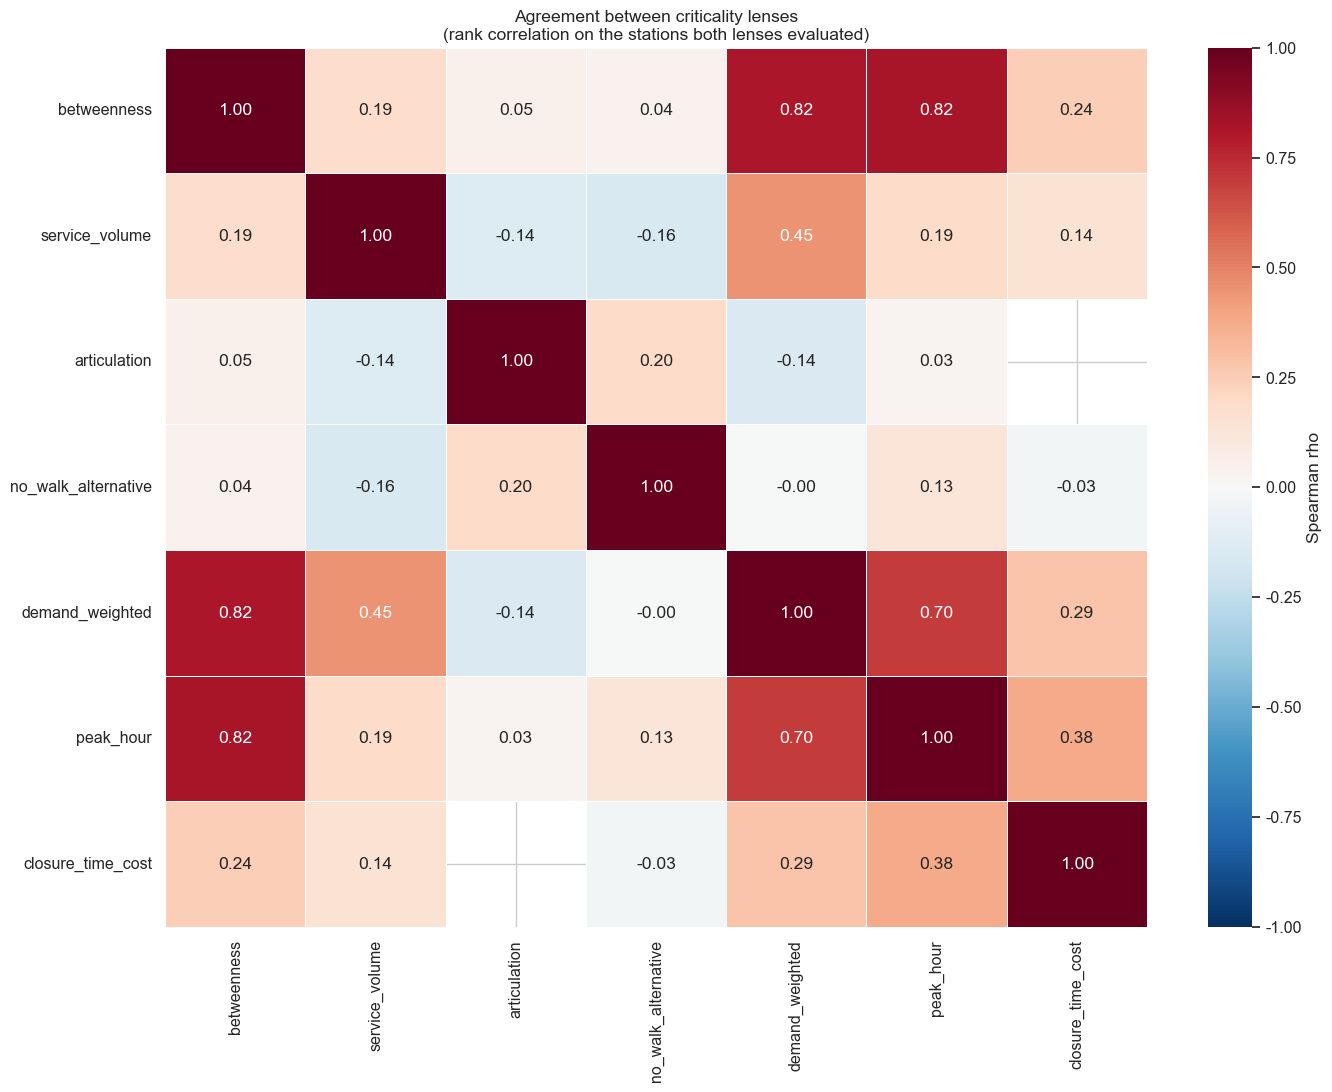

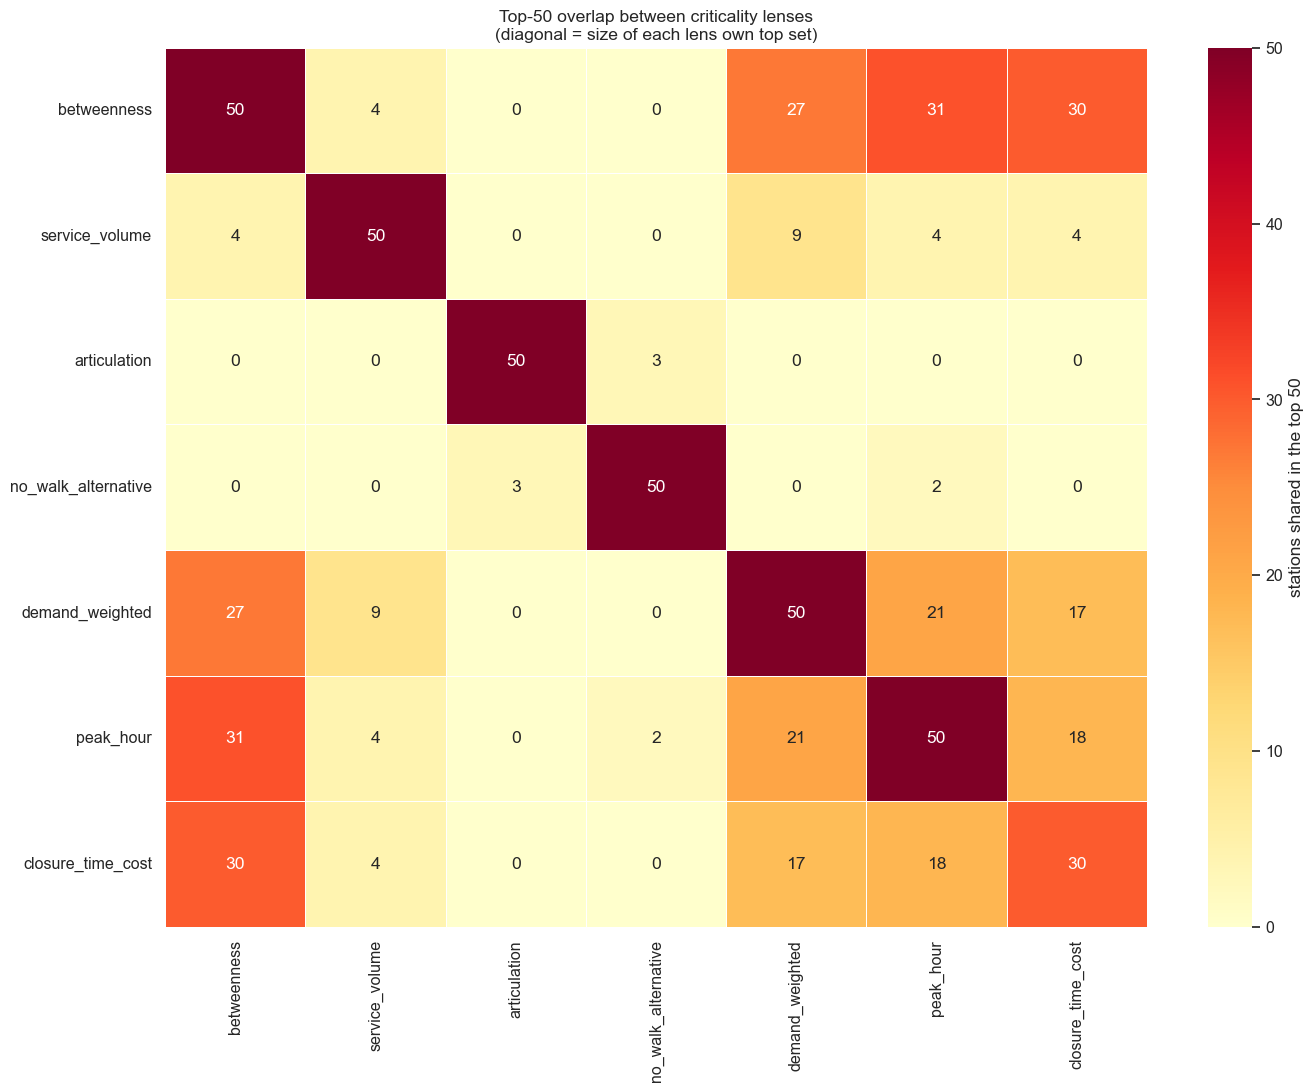

In [17]:
# --- Agreement heatmaps ----------------------------------------------------
rho_m = pd.DataFrame(np.nan, index=lens_names, columns=lens_names, dtype=float)
ovl_m = pd.DataFrame(0, index=lens_names, columns=lens_names, dtype=int)
for _, r in agreement.iterrows():
    a, b = r['lens_a'], r['lens_b']
    rho_m.loc[a, b] = rho_m.loc[b, a] = r['spearman_rho']
    ovl_m.loc[a, b] = ovl_m.loc[b, a] = int(r['top50_overlap'])
for n in lens_names:
    rho_m.loc[n, n] = 1.0
    ovl_m.loc[n, n] = len(topk_sets[n])

fig, ax = plt.subplots(figsize=(1.6 * len(lens_names) + 3, 1.3 * len(lens_names) + 2))
sns.heatmap(rho_m, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'label': 'Spearman rho'}, ax=ax)
ax.set_title('Agreement between criticality lenses\n'
             '(rank correlation on the stations both lenses evaluated)')
plt.tight_layout()
plt.savefig(FIGURES / 'lens_spearman_heatmap.png', dpi=FIG_DPI)
plt.show()

fig, ax = plt.subplots(figsize=(1.6 * len(lens_names) + 3, 1.3 * len(lens_names) + 2))
sns.heatmap(ovl_m, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': f'stations shared in the top {TOP_K}'}, ax=ax)
ax.set_title(f'Top-{TOP_K} overlap between criticality lenses\n'
             '(diagonal = size of each lens own top set)')
plt.tight_layout()
plt.savefig(FIGURES / 'lens_top_overlap_heatmap.png', dpi=FIG_DPI)
plt.show()

## 18. A profile per station: robustly critical vs. lens-dependent

Now we pivot the long table down to one row per station and attach three summary numbers:

* **`n_lenses_evaluated`** - how many lenses could score this station at all. This is the coverage denominator, and without it the next two numbers are unreadable.
* **`n_lenses_topk`** - in how many lenses' top 50 the station appears. This is the *evidence counter* and the primary sort key. Here, a station a lens never evaluated is correctly counted as "not flagged by that lens", because the claim being made to the planner is "how many independent definitions of criticality pick this station".
* **`consensus_mean_pct`** - the average percentile across the lenses that did evaluate it, used only as a tie-breaker. This number is *coverage-conditional* and must not be read as an overall score: a station seen by a single narrow lens can score 0.99 here on the strength of one opinion, which is exactly why the shortlist below also requires `n_lenses_evaluated >= MIN_LENSES_FOR_SHORTLIST`.

The two failure modes we separate are: **robust criticality** (several unrelated definitions independently point at the same station) and **lens-dependence** (exactly one lens flags it while others that did examine it didn't - usually a byproduct of that lens's definition, and sometimes a real blind spot in all the others).

In [18]:
# --- Wide per-station profile ----------------------------------------------
rank_wide = pd.concat([LENSES[n].set_index('stop_id')['rank'].rename(n)
                       for n in lens_names], axis=1)
pct_wide = pd.concat([LENSES[n].set_index('stop_id')['pct'].rename(n)
                      for n in lens_names], axis=1)
rank_wide.index.name = 'stop_id'
pct_wide.index.name = 'stop_id'
flags = rank_wide.le(TOP_K)          # NaN ranks compare False, which is what we want

prof = pd.DataFrame(index=pct_wide.index)
prof['n_lenses_evaluated'] = pct_wide.notna().sum(axis=1).astype(int)
prof['n_lenses_topk'] = flags.sum(axis=1).astype(int)
prof['consensus_mean_pct'] = pct_wide.mean(axis=1).round(4)
prof['lenses_topk'] = flags.apply(
    lambda row: ';'.join([c for c in flags.columns if bool(row[c])]), axis=1)
prof = prof.reset_index()

prof = prof.merge(rank_wide.add_prefix('rank_').reset_index(), on='stop_id', how='left')
prof = prof.merge(pct_wide.add_prefix('pct_').reset_index(), on='stop_id', how='left')
prof = prof.merge(spine, on='stop_id', how='left')


def reason_text(row):
    """Human-readable justification: which lenses flagged this station, and at what rank."""
    bits = [f'{n} (#{int(row["rank_" + n])})'
            for n in lens_names
            if pd.notna(row['rank_' + n]) and row['rank_' + n] <= TOP_K]
    return '; '.join(bits) if bits else 'in no lens top-' + str(TOP_K)


prof['reasons'] = prof.apply(reason_text, axis=1)
prof = prof.sort_values(['n_lenses_topk', 'consensus_mean_pct'],
                        ascending=[False, False]).reset_index(drop=True)
prof.to_csv(TABLES / 'station_lens_profile.csv', index=False, encoding='utf-8-sig')

dist = prof['n_lenses_topk'].value_counts().sort_index()
print('stations flagged by exactly k lenses:')
for k, v in dist.items():
    print(f'   k = {k}: {v:,} stations')
print(f'\nflagged by at least one lens: {int((prof["n_lenses_topk"] > 0).sum()):,}')
print(f'flagged by two or more lenses: {int((prof["n_lenses_topk"] >= 2).sum()):,}')

stations flagged by exactly k lenses:
   k = 0: 30,232 stations
   k = 1: 171 stations
   k = 2: 34 stations
   k = 3: 12 stations
   k = 4: 10 stations
   k = 5: 4 stations

flagged by at least one lens: 231
flagged by two or more lenses: 60


## 19. How concentrated is the evidence?

A bar chart of the number of stations flagged by exactly one lens, exactly two, and so on. The shape of this chart is the notebook's headline result. If almost every flagged station is flagged by exactly one lens, then "critical" is mostly a property of the measurement and not of the station, and no single ranking in this project should be presented as *the* answer. If a visible group is flagged by three or more lenses, those stations are the robust core - and the maximum possible value is the number of lenses available in this run, which the chart states in its title.

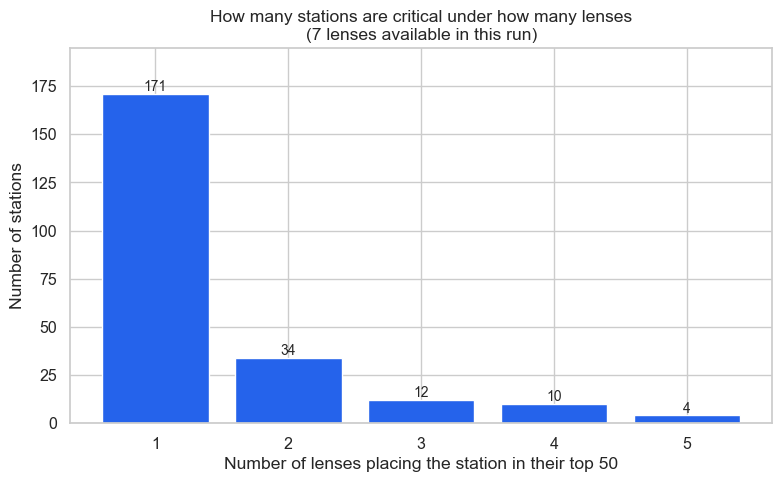

In [19]:
# --- Distribution of evidence across lenses --------------------------------
flagged = prof[prof['n_lenses_topk'] > 0]
counts = flagged['n_lenses_topk'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(k) for k in counts.index], counts.to_numpy(), color='#2563eb')
for bar, val in zip(bars, counts.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel(f'Number of lenses placing the station in their top {TOP_K}')
ax.set_ylabel('Number of stations')
ax.set_title(f'How many stations are critical under how many lenses\n'
             f'({len(lens_names)} lenses available in this run)')
ax.margins(y=0.14)
plt.tight_layout()
plt.savefig(FIGURES / 'stations_by_lens_count.png', dpi=FIG_DPI)
plt.show()

## 20. The shortlist

The practical product. A station makes the shortlist only if it was evaluated by at least `MIN_LENSES_FOR_SHORTLIST` lenses (so nothing enters on the strength of a single narrow opinion) and appears in the top 50 of at least one lens. The sort order is: the number of lenses that flag it, then the average percentile as a tie-breaker.

Every row carries a `reasons` string spelling out exactly which lenses flagged it and at what rank, so the list is auditable - a planner can see that a station appears here because it's a cut vertex isolating 400 stations *and* the busiest transfer hub in its district, versus a station that's here on betweenness alone. The per-lens `rank_*` columns are kept in the exported file for the same reason.

This is a shortlist, not a budget. It ranks stations by how much independent evidence there is that they matter - not by repair cost, not by failure probability, and not by anything the GTFS file can't see (station configuration, staffing, actual passenger counts).

In [20]:
# --- Final ranked shortlist ------------------------------------------------
eligible = prof[(prof['n_lenses_evaluated'] >= MIN_LENSES_FOR_SHORTLIST)
                & (prof['n_lenses_topk'] >= 1)].copy()
shortlist = (eligible.sort_values(['n_lenses_topk', 'consensus_mean_pct'],
                                  ascending=[False, False])
             .head(SHORTLIST_SIZE)
             .reset_index(drop=True))
shortlist.insert(0, 'shortlist_rank', np.arange(1, len(shortlist) + 1))

front = ['shortlist_rank', 'stop_id', 'stop_name', 'region', 'lat', 'lon',
         'n_lenses_topk', 'n_lenses_evaluated', 'consensus_mean_pct', 'reasons']
front = [c for c in front if c in shortlist.columns]
rest = [c for c in shortlist.columns if c not in front]
shortlist = shortlist[front + rest]
shortlist.to_csv(TABLES / 'critical_station_shortlist.csv', index=False, encoding='utf-8-sig')

print(f'{len(eligible):,} stations were eligible; the top {len(shortlist)} are exported.')
shortlist[['shortlist_rank', 'stop_name', 'region', 'n_lenses_topk',
           'consensus_mean_pct', 'reasons']].head(TOP_N_FIG)

231 stations were eligible; the top 40 are exported.


,shortlist_rank,stop_name,region,n_lenses_topk,consensus_mean_pct,reasons
0,1,מחלף חמד,Jerusalem,5,0.8978,betweenness (#5); service_volume (#48); demand...
1,2,מחלף חמד,Jerusalem,5,0.8374,betweenness (#2); service_volume (#49); demand...
2,3,מחלף גבעת שמואל/כביש 4,Center,5,0.8348,betweenness (#17); service_volume (#22); deman...
3,4,ויצמן/גבעת שאול,Jerusalem,5,0.7292,betweenness (#28); service_volume (#37); deman...
4,5,מחלף גהה/דרך ז'בוטינסקי,Center,4,0.9129,betweenness (#21); demand_weighted (#18); peak...
5,6,דרך האר''י/ כביש 375,Jerusalem,4,0.8632,betweenness (#4); demand_weighted (#2); peak_h...
6,7,מחלף קסם,Center,4,0.8586,betweenness (#8); demand_weighted (#26); peak_...
7,8,בן גוריון/שערי ירושלים,Jerusalem,4,0.8233,betweenness (#11); demand_weighted (#21); peak...
8,9,מחלף קמה לצפון,South,4,0.8180,betweenness (#3); demand_weighted (#6); peak_h...
9,10,מחלף קסם,Center,4,0.7980,betweenness (#18); demand_weighted (#47); peak...


## 21. Heatmap of the shortlist profile

One row per shortlist station, one column per lens, colored by the station's percentile within that lens (1.0 = the most critical station that lens ever saw, 0 = the least). Gray gaps are *not evaluated* - the station is outside that lens's coverage - and they're drawn distinctly from a genuine low score, because those two indicate opposite things.

A row that's dark all the way across is a station every definition agrees on. A row with one dark cell and the rest pale is a station riding on a single lens, the visual counterpart of the lens-dependence table in section 23. The station names are in Hebrew and pass through the bidi patch installed in section 3; the numeric station id is appended to them because some stations share a name.

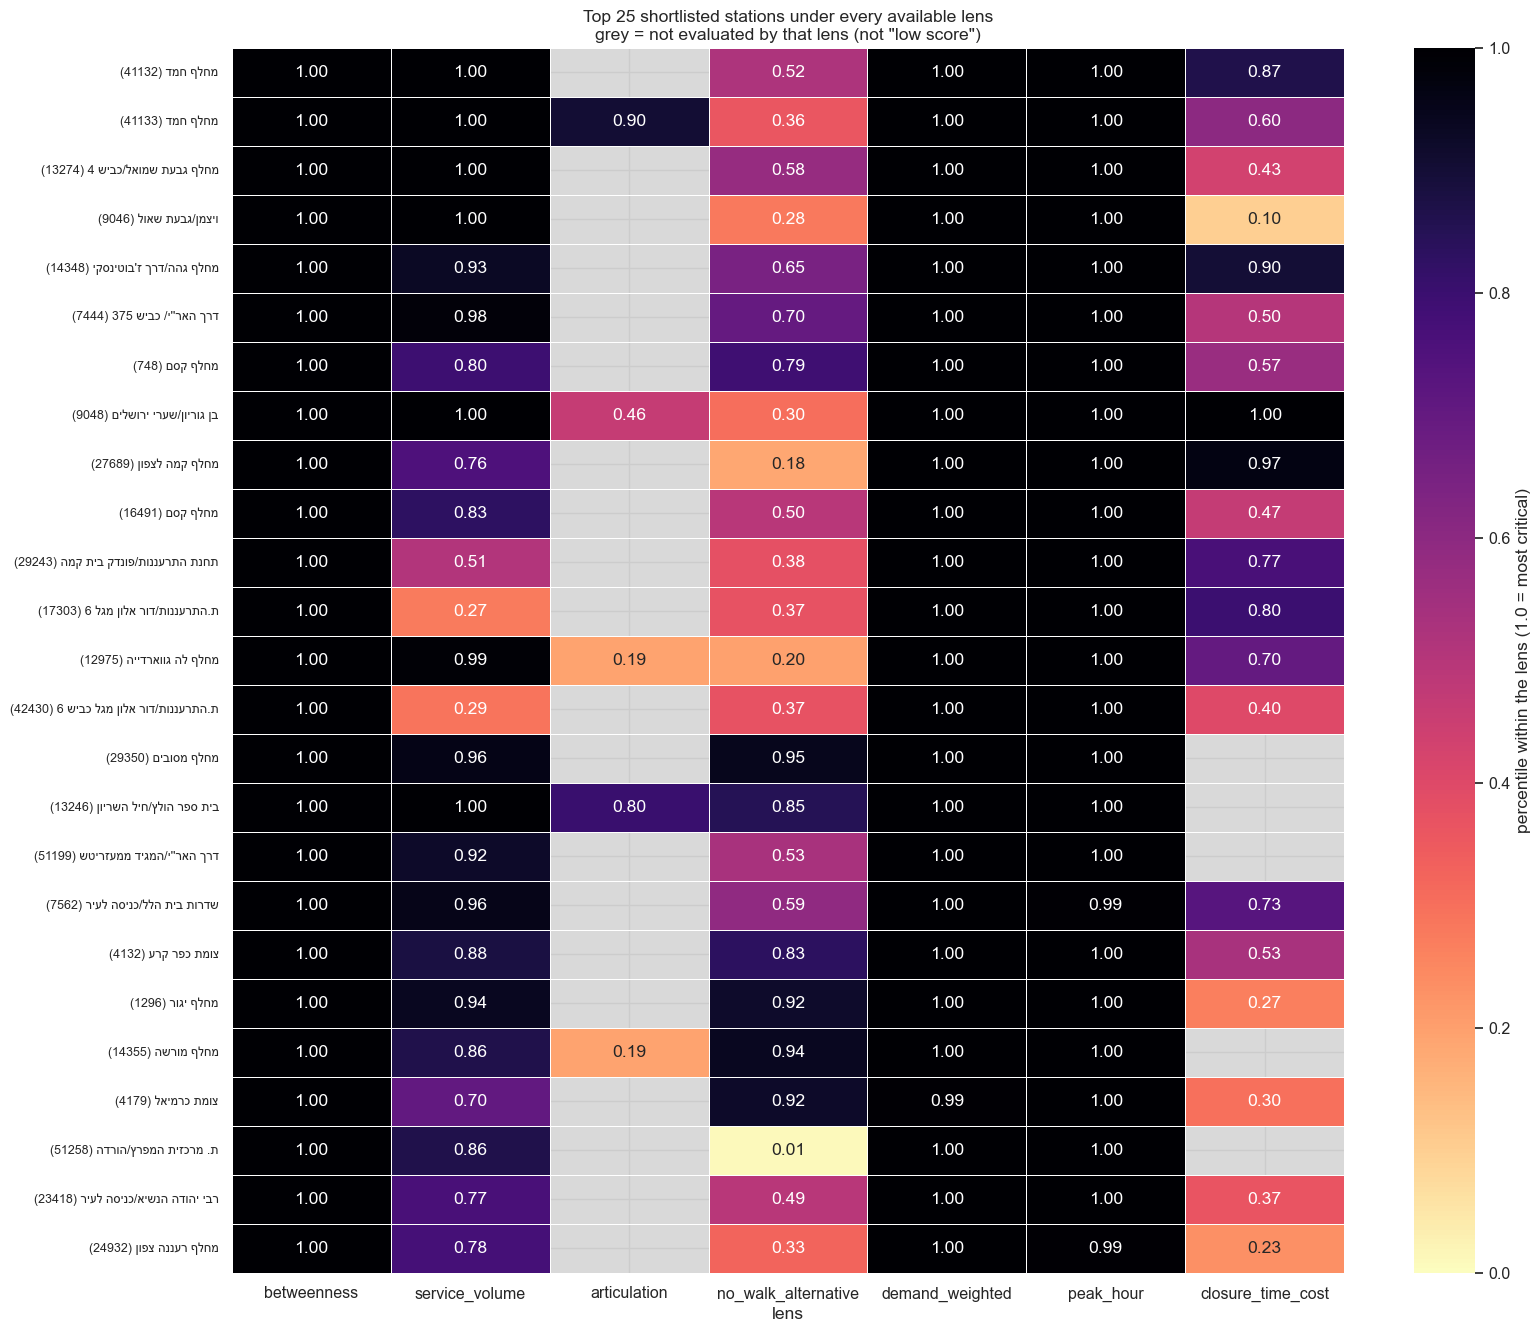

In [21]:
# --- Shortlist profile heatmap ---------------------------------------------
top_rows = shortlist.head(TOP_N_FIG).copy()
pct_cols = ['pct_' + n for n in lens_names]
mat = top_rows[pct_cols].astype(float)
mat.columns = lens_names
mat.index = [f'{name} ({sid})' for name, sid
             in zip(top_rows['stop_name'].fillna('?'), top_rows['stop_id'])]

fig, ax = plt.subplots(figsize=(1.5 * len(lens_names) + 6, 0.42 * len(mat) + 3))
sns.heatmap(mat, annot=True, fmt='.2f', cmap='magma_r', vmin=0, vmax=1,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'percentile within the lens (1.0 = most critical)'},
            mask=mat.isna(), ax=ax)
ax.set_facecolor('#d9d9d9')          # grey = the lens never evaluated this station
ax.set_title(f'Top {len(mat)} shortlisted stations under every available lens\n'
             'grey = not evaluated by that lens (not "low score")')
ax.set_xlabel('lens')
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'shortlist_lens_profile.png', dpi=FIG_DPI)
plt.show()

## 22. Where the shortlist sits

The shortlist is plotted over the full station cloud, with station size and color set by the number of lenses that flagged it. This is a plain latitude/longitude scatter rather than a projected map, so the aspect ratio is set to `1 / cos(mean latitude)` to keep the shape of the country roughly right instead of stretched sideways.

Geography matters for interpretation: if the shortlist all clusters in the Tel Aviv - Haifa corridor, then the synthesis is mostly rediscovering where the network is densest, and the periphery - where a single failure has far fewer alternatives - is under-represented by all the lenses at once.

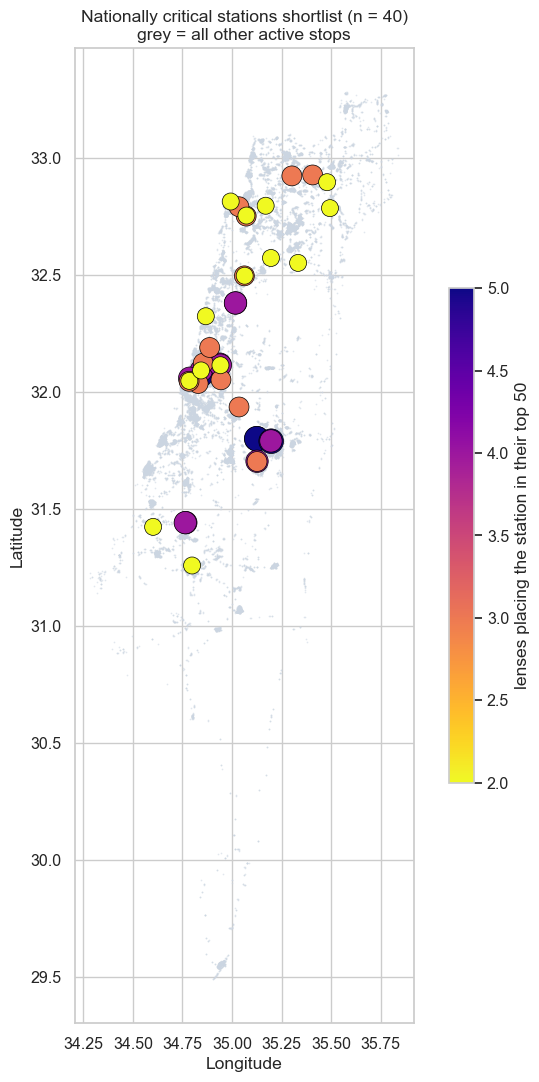

shortlist by region:
region
Center       19
North        11
Jerusalem     6
South         4


In [22]:
# --- Map of the shortlist --------------------------------------------------
base = spine.dropna(subset=['lat', 'lon'])
pts = shortlist.dropna(subset=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(8, 11))
ax.scatter(base['lon'], base['lat'], s=1.5, color='#cbd5e1', alpha=0.55, linewidths=0)
if len(pts):
    sc = ax.scatter(pts['lon'], pts['lat'], c=pts['n_lenses_topk'],
                    s=40 + 55 * pts['n_lenses_topk'], cmap='plasma_r',
                    edgecolor='black', linewidths=0.5, zorder=3)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.035)
    cbar.set_label(f'lenses placing the station in their top {TOP_K}')
    ax.set_aspect(1 / np.cos(np.deg2rad(float(base['lat'].mean()))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Nationally critical stations shortlist (n = {len(pts)})\n'
             'grey = all other active stops')
plt.tight_layout()
plt.savefig(FIGURES / 'shortlist_map.png', dpi=FIG_DPI)
plt.show()

if 'region' in shortlist.columns:
    print('shortlist by region:')
    print(shortlist['region'].fillna('Unknown').value_counts().to_string())

## 23. Lens-dependent stations: the byproducts

The mirror image of the shortlist. These are stations that exactly one lens places in its top 50 **while at least one other lens examined them and did not**. The second condition is what makes the finding meaningful: a station flagged by one lens and simply invisible to all the others is a coverage gap, not a disagreement.

Most of them are byproducts of definitions, and it's worth naming them because each is a warning about the lens that produced it - a cut vertex on a dead-end branch that no passenger volume justifies, a station with a huge `nearest_alt_m` because it stands alone in the desert, a multimodal station that's multimodal only because two route types happen to share the same curb. The per-lens counts tell you which lens is the most idiosyncratic: the lens contributing the most single-lens flags is the one whose ranking least deserves to be used on its own.

171 stations are flagged by exactly one lens while at least one other lens evaluated them and did not flag them.


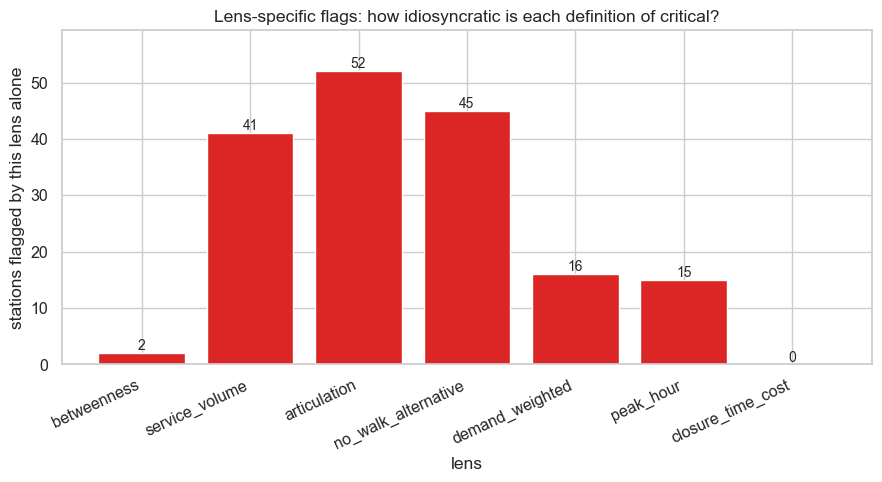

,stop_id,stop_name,region,lat,lon,only_lens,n_lenses_evaluated,consensus_mean_pct,reasons
107,11221,קיבוץ מעלה החמישה,Jerusalem,31.818536,35.111899,articulation,6,0.8608,articulation (#9)
115,7935,טורקיז/ענבר,Center,31.962056,35.065781,articulation,6,0.8408,articulation (#4)
136,39840,טבעת דרומית,Center,32.257872,35.004816,articulation,5,0.7946,articulation (#23)
138,11227,צומת אורה,Jerusalem,31.757147,35.159936,articulation,6,0.7915,articulation (#9)
141,15949,מחמוד דרוויש/אלבוחארי,Center,32.257506,35.006394,articulation,6,0.7828,articulation (#23)
143,20128,איבטין טחנת קמח,North,32.763357,35.106344,articulation,6,0.7772,articulation (#9)
144,35529,כפר הנשיא,North,32.974481,35.603560,articulation,5,0.7764,articulation (#14)
147,17861,אדמית מרכז,North,33.079481,35.211363,articulation,6,0.7681,articulation (#6)
148,34581,'איתמר א,Center,32.175204,35.308726,articulation,5,0.7681,articulation (#23)
159,50832,האלון/הרימון,North,32.619844,35.074935,articulation,6,0.7238,articulation (#8)


In [23]:
# --- Stations flagged by exactly one lens ----------------------------------
single = prof[(prof['n_lenses_topk'] == 1)
              & (prof['n_lenses_evaluated'] >= 2)].copy()
single['only_lens'] = single['lenses_topk']
single_out = single[['stop_id', 'stop_name', 'region', 'lat', 'lon', 'only_lens',
                     'n_lenses_evaluated', 'consensus_mean_pct', 'reasons']]
single_out = single_out.sort_values(['only_lens', 'consensus_mean_pct'],
                                    ascending=[True, False])
single_out.to_csv(TABLES / 'lens_specific_stations.csv', index=False, encoding='utf-8-sig')

per_lens = single['only_lens'].value_counts().reindex(lens_names).fillna(0).astype(int)
print(f'{len(single):,} stations are flagged by exactly one lens while at least one '
      'other lens evaluated them and did not flag them.')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(per_lens.index.astype(str), per_lens.to_numpy(), color='#dc2626')
for bar, val in zip(bars, per_lens.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('lens')
ax.set_ylabel('stations flagged by this lens alone')
ax.set_title('Lens-specific flags: how idiosyncratic is each definition of critical?')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
ax.margins(y=0.14)
plt.tight_layout()
plt.savefig(FIGURES / 'lens_specific_counts.png', dpi=FIG_DPI)
plt.show()

single_out.head(15)

## 24. The summary record

A single JSON file holding the headline numbers, which lenses were available and which weren't, the mean and range of the pairwise agreement, and the head of the shortlist. Written last so it always describes the run that just happened - including, and this matters, which lenses were missing, so that a reader of the JSON alone can't mistake a four-lens run for a seven-lens run.

In [24]:
# --- Summary JSON ----------------------------------------------------------
rho_vals = agreement['spearman_rho'].dropna()
top_rows_json = shortlist.head(10)[['shortlist_rank', 'stop_id', 'stop_name',
                                    'n_lenses_topk', 'consensus_mean_pct', 'reasons']]

summary = {
    'stations_in_universe': int(len(spine)),
    'top_k_definition': int(TOP_K),
    'lenses_available': lens_names,
    'lenses_missing': [{'lens': a, 'needs': b, 'missing': c} for a, b, c in MISSING_LENSES],
    'lens_coverage': {n: LENS_META[n]['stations_evaluated'] for n in lens_names},
    'lens_pairs_compared': int(len(agreement)),
    'spearman_rho_mean': round(float(rho_vals.mean()), 4) if len(rho_vals) else None,
    'spearman_rho_min': round(float(rho_vals.min()), 4) if len(rho_vals) else None,
    'spearman_rho_max': round(float(rho_vals.max()), 4) if len(rho_vals) else None,
    'top_k_overlap_mean': round(float(agreement['top50_overlap'].mean()), 2),
    'stations_flagged_by_any_lens': int((prof['n_lenses_topk'] > 0).sum()),
    'stations_flagged_by_two_or_more': int((prof['n_lenses_topk'] >= 2).sum()),
    'stations_flagged_by_three_or_more': int((prof['n_lenses_topk'] >= 3).sum()),
    'stations_flagged_by_exactly_one': int(len(single)),
    'max_lenses_agreeing_on_one_station': int(prof['n_lenses_topk'].max()),
    'shortlist_size': int(len(shortlist)),
    'unreachable_penalty_seconds': int(UNREACHABLE_PENALTY_SECONDS),
    'articulation_severity_exact': bool(AP_SEVERITY_EXACT),
    'shortlist_top10': top_rows_json.to_dict(orient='records'),
}

with open(STAGE / 'lens_synthesis_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2)

print(json.dumps({k: v for k, v in summary.items() if k != 'shortlist_top10'},
                 ensure_ascii=False, indent=2))
print('\nfiles written under', STAGE)
for p in sorted(STAGE.rglob('*')):
    if p.is_file():
        print('   ', p.relative_to(STAGE))

{
  "stations_in_universe": 30463,
  "top_k_definition": 50,
  "lenses_available": [
    "betweenness",
    "service_volume",
    "articulation",
    "no_walk_alternative",
    "demand_weighted",
    "peak_hour",
    "closure_time_cost"
  ],
  "lenses_missing": [],
  "lens_coverage": {
    "betweenness": 30463,
    "service_volume": 30463,
    "articulation": 900,
    "no_walk_alternative": 3047,
    "demand_weighted": 30463,
    "peak_hour": 30057,
    "closure_time_cost": 30
  },
  "lens_pairs_compared": 21,
  "spearman_rho_mean": 0.2096,
  "spearman_rho_min": -0.1582,
  "spearman_rho_max": 0.8232,
  "top_k_overlap_mean": 8.1,
  "stations_flagged_by_any_lens": 231,
  "stations_flagged_by_two_or_more": 60,
  "stations_flagged_by_three_or_more": 26,
  "stations_flagged_by_exactly_one": 171,
  "max_lenses_agreeing_on_one_station": 5,
  "shortlist_size": 40,
  "unreachable_penalty_seconds": 3600,
  "articulation_severity_exact": true
}

files written under C:\Users\Sean-PC\Desktop\LAST S

## Conclusions

* **"Critical" isn't one property, and this notebook is the proof.** Seven definitions were compared; each produces a different top 50, and the Spearman matrix in section 17 shows how far apart they are. The two lenses that come from the same table (betweenness and service volume) agree the most, and that's a sanity check rather than a finding; the interesting numbers are the off-diagonal cells that link lenses built from different data - structure, walking distance, passenger seconds, and demand weight.
* **Rank correlation and top-50 overlap tell different stories, and the top-50 overlap is the one that matters.** Two lenses can correlate strongly across 30,000 stations - because they agree that the vast majority of stations are unremarkable - and still share very few names right at the top. Any claim in this project of the form "station X is the most critical in the country" is a claim about one lens, and section 16 quantifies how little of it survives a change of definition.
* **A small robust core does exist.** The stations that several unrelated lenses independently place in their top 50 are the defensible answer to the project's research question. They're exported in `critical_station_shortlist.csv` together with the justification for each, and they're the only stations in this project supported by more than one kind of evidence.
* **The single-lens flags are mostly byproducts, and naming them is part of the result.** A cut vertex on a dead-end branch, a station with no walking alternative because nothing else is within a kilometer of it - each of these is a real consequence of its lens's definition and not a national vulnerability. `lens_specific_stations.csv` lists them, and the bar chart in section 23 shows which lens is the most idiosyncratic.
* **Honest limitations.** (1) Coverage isn't equal: the walking-alternative lens ever saw only about 10% of the network, pre-filtered, so its correlations are computed on that subset and its absence from a station means "not measured", not "fine". (2) `consensus_mean_pct` is coverage-conditional and used only as a tie-breaker, never as a headline score. (3) The betweenness lens is a sampling-based approximation with an unstable tail, so small rank differences are noise. (4) The closure-cost lens depends on `UNREACHABLE_PENALTY_SECONDS`, which is an assumption about what an impossible trip costs, not a measurement. (5) Everything here is derived from the schedule: the GTFS file contains no passenger counts, so "demand" is always a population proxy and any statement about passengers inherits that.
* **What a planner should take from this.** Don't act on any single ranking in this project. Act on the intersection - and when a station is flagged by only one lens, treat that as a question to look into rather than an answer, because the lens that flagged it is telling you something specific about *why* it might matter.